# Jigsaw Dataset Sampling and Refinement
> **Goal:** Integrate Jigsaw Toxic Comments with Unintended Bias data to create a high-quality, stratified training subset.

In this stage, we move from raw data exploration to final dataset construction. We focus on balancing four distinct categories of text to ensure the model learns toxicity without inheriting identity-based biases.

## Sampling Strategy
To optimize for both toxicity detection and bias mitigation, we are targeting the following distribution:
* **Toxic Plain:** ~14,500 samples (Toxic language, no identity mention)
* **Toxic Identity:** ~5,500 samples (Toxic attacks targeting specific groups)
* **Clean Identity:** 8,000 samples (Neutral/Positive mentions of protected groups)
* **Clean Plain:** 32,000 samples (General safe conversation)

## Key Operations
1. **Data Integration:** Merging the Jigsaw Toxicity and Unintended Bias CSVs.
2. **Stratified Sampling:** Implementing a balanced sampling strategy across all label combinations.
3. **Final Export:** Saving the refined dataset for model training.

## Importing Dependencies

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
from toxicity_detector.utils.plotting import *
from toxicity_detector.config import JIGSAW_TOXIC_RAW, JIGSAW_BIAS_RAW, JIGSAW_INTERIM

pd.set_option("display.max_colwidth", None)

## Loading Data

In [2]:
tc_df = pd.read_csv(JIGSAW_TOXIC_RAW["combined"])
ub_df = pd.read_csv(JIGSAW_BIAS_RAW["combined"])
print(f"Jigsaw Toxic Comments Dataset: {tc_df.shape}")
print(f"Unintended Bias in Toxicity Classification Dataset: {ub_df.shape}")

Jigsaw Toxic Comments Dataset: (223549, 10)
Unintended Bias in Toxicity Classification Dataset: (383497, 20)


# 1.0 Data Integration

In [3]:
toxicity_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
identity_categories = ["male", "female", "homosexual_gay_or_lesbian", "christian", "jewish", "muslim", "black", "white", "psychiatric_or_mental_illness"]

In [4]:
# Align column names for easier handling
ub_df.rename(columns={"toxicity": "toxic", "severe_toxicity": "severe_toxic", "identity_attack": "identity_hate"}, inplace=True)

In [5]:
# Adding absent columns to make both dataframes consistent
tc_df[identity_categories + ["category_count"]] = 0
tc_df.shape[1], ub_df.shape[1]

(20, 20)

In [6]:
# Check how many unique comments are in each dataset
print(f"Unique comments in Jigsaw Toxic Comments Dataset: {tc_df['comment_text'].nunique()}")
print(f"Unique comments in Unintended Bias in Toxicity Classification Dataset: {ub_df['comment_text'].nunique()}")

Unique comments in Jigsaw Toxic Comments Dataset: 223549
Unique comments in Unintended Bias in Toxicity Classification Dataset: 380716


In [7]:
ub_df.drop_duplicates(subset=["comment_text"], inplace=True)
ub_df.shape

(380716, 20)

**Combining Datasets**

In [8]:
df = pd.concat([tc_df, ub_df], ignore_index=True)
df.shape

(604265, 20)

In [9]:
# Check for duplicates in the combined dataset
print(f"Unique comments in the combined dataset: {df['comment_text'].nunique()}")

Unique comments in the combined dataset: 604247


In [10]:
df.drop_duplicates(subset=["comment_text"], inplace=True)
df.shape

(604247, 20)

In [11]:
df["label_count"] = df[toxicity_columns].sum(axis=1)
df["category_count"] = df[identity_categories].sum(axis=1)

In [12]:
# Count of toxic vs non-toxic comments
df["label_count"].value_counts().sort_values(ascending=False)

label_count
0    435429
2    113898
1     35972
3     15599
4      2740
5       562
6        47
Name: count, dtype: int64

In [13]:
# Count of identity categories presence in toxic comments
df[df["label_count"] > 0]["category_count"].value_counts().sort_values(ascending=False)

category_count
0    140728
1     18356
2      7253
3      1938
4       438
5        80
6        21
7         4
Name: count, dtype: int64

In [14]:
# Count of identity categories presence in non-toxic comments
df[df["label_count"] == 0]["category_count"].value_counts().sort_values(ascending=False)

category_count
0    300618
1     97481
2     30381
3      5719
4      1034
5       163
6        19
7        12
8         2
Name: count, dtype: int64

# 2.0 Dataset Sampling

In [15]:
# Defining amounts of comments for each dataset (toxic, identity rich toxic, identity rich non-toxic, plain non-toxic)
n_identity_rich_samples = 8000
n_plain_samples = 32000

In [16]:
toxic_df = df[df["label_count"] > 0]
identity_df = df[(df["label_count"] == 0) & (df["category_count"] > 0)]
plain_non_toxic_df = df[(df["label_count"] == 0) & (df["category_count"] == 0)]

toxic_df.shape, identity_df.shape, plain_non_toxic_df.shape

((168818, 20), (134811, 20), (300618, 20))

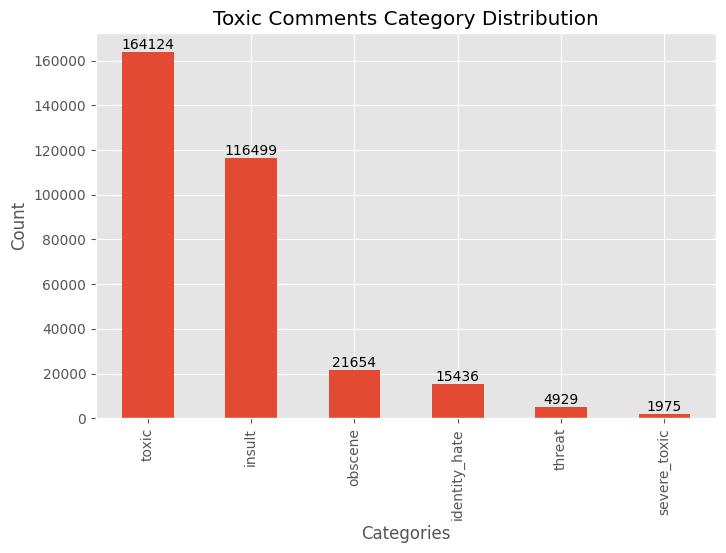

In [17]:
plot_category_distribution(toxic_df, toxicity_columns, title="Toxic Comments Category Distribution")

In [18]:
for col in toxicity_columns:
    cat_df = df[df[col] == 1]
    cooccurrence_counts = cat_df["label_count"].value_counts().sort_index()
    
    fig = px.pie(cooccurrence_counts, values=cooccurrence_counts.values, names=cooccurrence_counts.index, title=f"Co-occurrence Counts Distribution for '{col}' in Toxic Comments", width=800, height=500)
    fig.show()

### 2.1 Sampling Toxic Coments

The toxic subset was constructed using the following strategy:

1. All comments with `label_count > 3` were included, as they represent rare multi-label and hard examples that support robust multi-label learning.
2. All comments labeled as `severe_toxic` or threat were retained due to the low frequency and high importance of these categories.
3. A controlled number of samples from more frequent categories (such as `obscene`, `insult`, and `identity_hate`) were randomly selected to prevent class dominance.
4. Additional samples were included to balance identity-related categories, aiming for an approximately uniform distribution across identities.

In [19]:
def num_comments_retained(df):
    return df[df["keep"] == 1].shape

In [20]:
# As there are not so many comments with `label_count` > 3, we'll use them all
toxic_df = toxic_df.copy()
toxic_df["keep"] = 0
toxic_df["keep"] = (toxic_df["label_count"] > 3).astype(int)

In [21]:
# Adding comments with `severe_toxic` or `threat`
toxic_df.loc[(toxic_df["severe_toxic"] == 1) | (toxic_df["threat"] == 1), "keep"] = 1

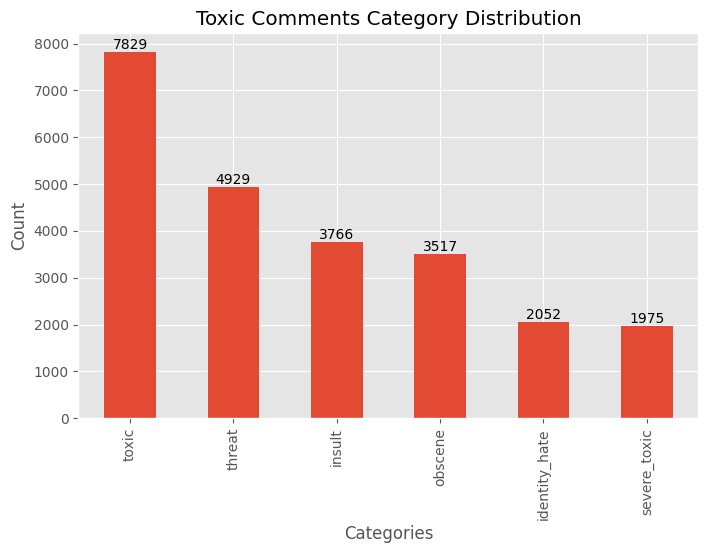

In [22]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], toxicity_columns, title="Toxic Comments Category Distribution")

In [23]:
def add_category_samples(df, category, n_samples, cat_count=2, lab_count=2):
    """
    Add comments with `category` presence and `label_count` == `lab_count` and `category_count` <= `cat_count`.
    """
    candidates = df[
        (df[category] == 1) &
        (df["keep"] == 0) &
        (df["label_count"] == lab_count) &
        (df["category_count"] <= cat_count)
    ]
    
    n = min(len(candidates), n_samples)
    selected_idx = np.random.choice(candidates.index, size=n, replace=False)
    
    df.loc[selected_idx, "keep"] = 1

In [24]:
add_category_samples(toxic_df, "obscene", 1600, 0)
add_category_samples(toxic_df, "insult", 800, 0)
add_category_samples(toxic_df, "identity_hate", 2000, 0, 1)
add_category_samples(toxic_df, "identity_hate", 2500, 0)

add_category_samples(toxic_df, "obscene", 1300, 0, 3)
add_category_samples(toxic_df, "insult", 800, 0, 3)
add_category_samples(toxic_df, "identity_hate", 2500, 0, 3)

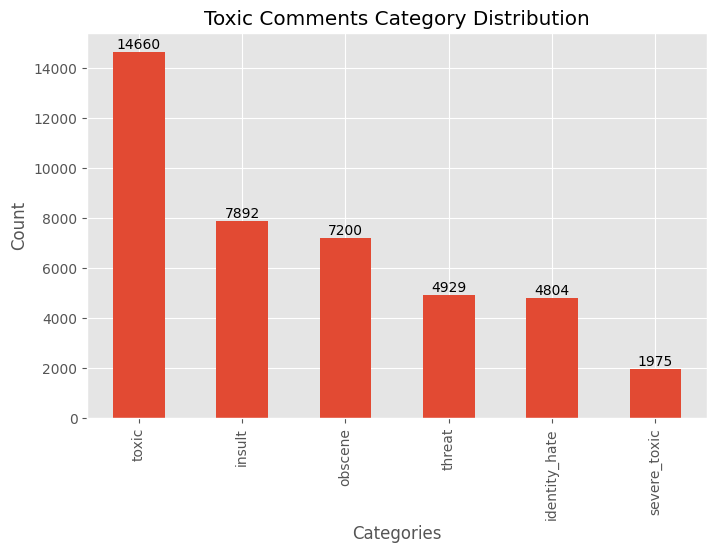

In [25]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], toxicity_columns, title="Toxic Comments Category Distribution")

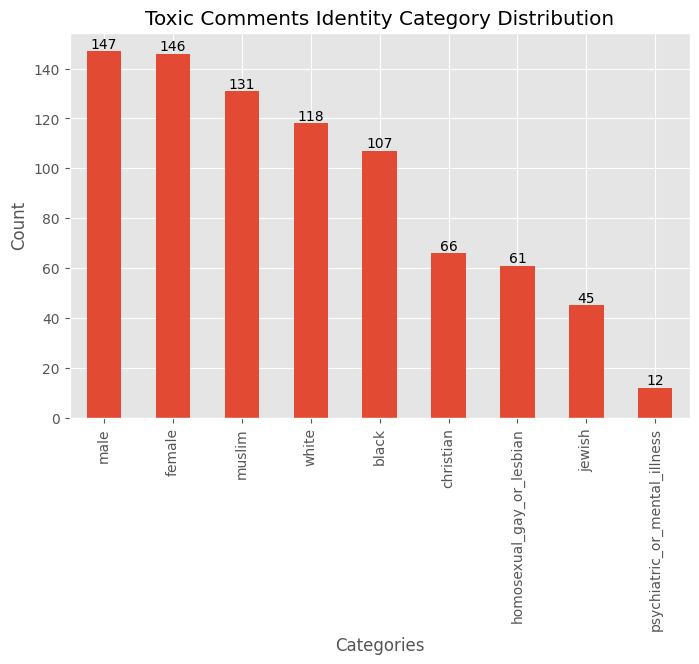

In [26]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], identity_categories, title="Toxic Comments Identity Category Distribution")

In [27]:
first_set = ["white", "black", "muslim", "male", "female", "christian", "homosexual_gay_or_lesbian"]
second_set = ["jewish", "psychiatric_or_mental_illness"]

for category in first_set:
    add_category_samples(toxic_df, category, 200, 2, 1)
    add_category_samples(toxic_df, category, 100, 2, 2)
    add_category_samples(toxic_df, category, 100, 2, 3)
    
for category in second_set:
    add_category_samples(toxic_df, category, 500, 2, 1)
    add_category_samples(toxic_df, category, 300, 2, 2)
    add_category_samples(toxic_df, category, 300, 2, 3)

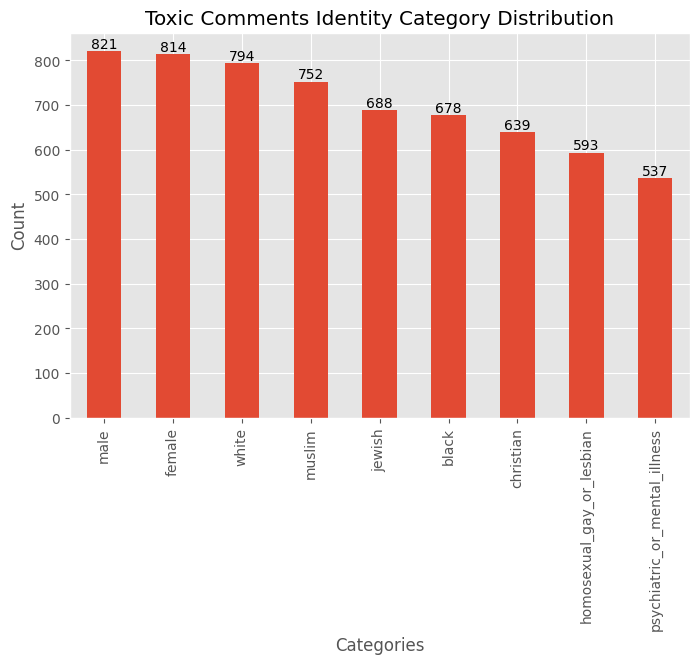

In [28]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], identity_categories, title="Toxic Comments Identity Category Distribution")

In [29]:
num_comments_retained(toxic_df[toxic_df["category_count"] > 0])

(4513, 21)

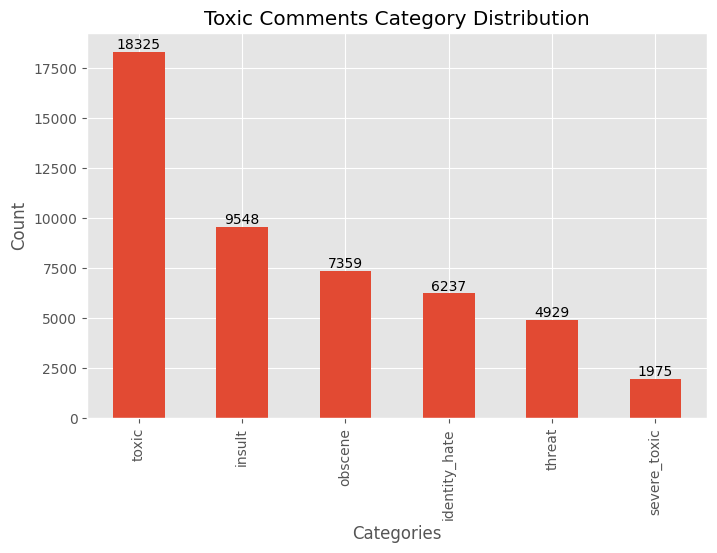

In [30]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], toxicity_columns, title="Toxic Comments Category Distribution")

In [31]:
# Adding comments with `identity_hate`
add_category_samples(toxic_df, "identity_hate", 200, 1, 2)
add_category_samples(toxic_df, "identity_hate", 200, 2, 2)
add_category_samples(toxic_df, "identity_hate", 200, 3, 2)

In [32]:
for cat in second_set + first_set[5:]:
    # Adding some comments with the least common identity categories 
    add_category_samples(toxic_df, cat, 200, 1, 3)
    add_category_samples(toxic_df, cat, 100, 2, 3)

In [33]:
num_comments_retained(toxic_df)

(20035, 21)

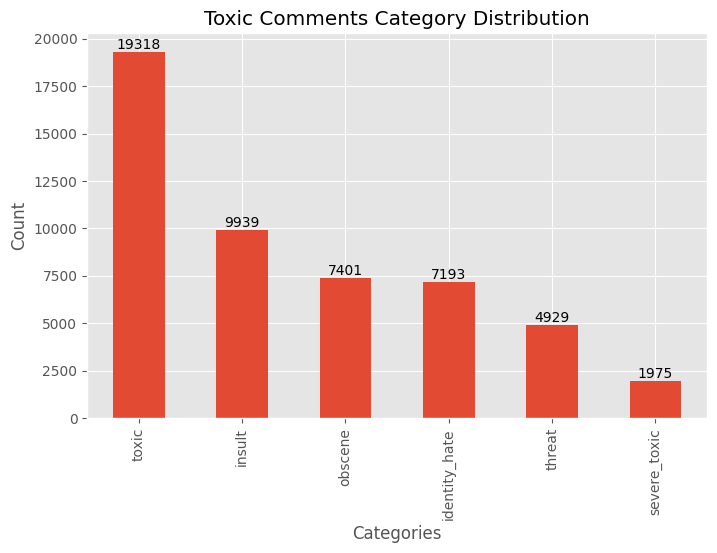

In [34]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], toxicity_columns, title="Toxic Comments Category Distribution")

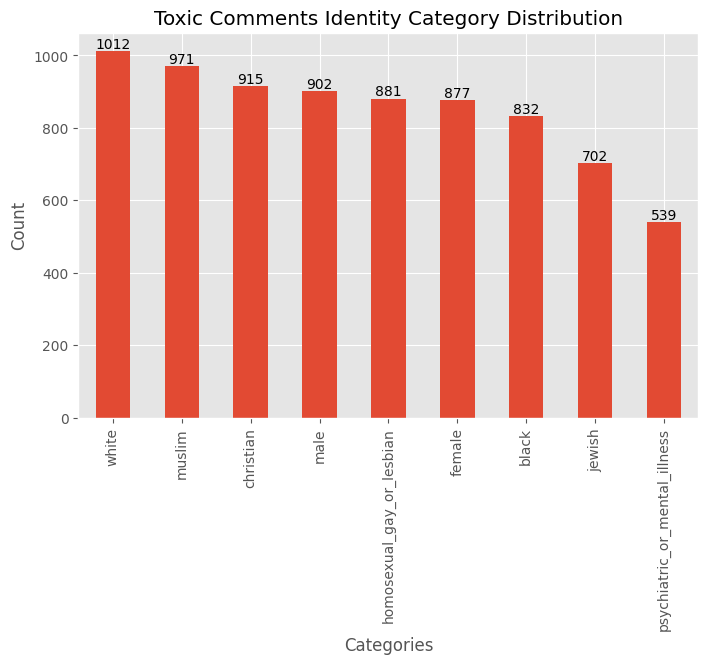

In [35]:
plot_category_distribution(toxic_df[toxic_df["keep"] == 1], identity_categories, title="Toxic Comments Identity Category Distribution")

In [36]:
num_comments_retained(toxic_df[toxic_df["category_count"] > 0])

(5507, 21)

In [37]:
toxic_sample = toxic_df[toxic_df["keep"] == 1].drop(columns=["keep"])
toxic_sample.shape

(20035, 20)

### 2.2 Sampling Non-Toxic Comments

In [ ]:
# Remove comments that mention "wikipedia" in the plain non-toxic sample
is_not_wikipedia = ~plain_non_toxic_df["comment_text"].str.contains("wikipedia", case=False, na=False)
plain_non_toxic_sample = plain_non_toxic_df[is_not_wikipedia].sample(n=n_plain_samples, random_state=42)

In [39]:
def select_comments_by_identity(df, categories, n_samples):
    df["keep"] = 0
    samples_per_category = n_samples // len(categories)
    
    for category in categories:
        category_comments = df[df[category] == 1]
        category_comments = category_comments.sort_values(by="category_count", ascending=True)
        sampled_comments = category_comments.head(n=samples_per_category)
        df.loc[sampled_comments.index, "keep"] = 1

In [40]:
# Sampling identity rich non-toxic comments
select_comments_by_identity(identity_df, identity_categories, n_identity_rich_samples)
identity_sample = identity_df[identity_df["keep"] == 1].drop(columns=["keep"])

## 3.0 Data Splitting and Export

In [41]:
final_df = pd.concat([toxic_sample, plain_non_toxic_sample, identity_sample], ignore_index=True)
final_df.shape

(60027, 20)

### 3.1 Train–Test Split

In [42]:
def rule_based_train_test_split(
    df,
    toxicity_columns=toxicity_columns,
    identity_categories=identity_categories,
    test_size=0.2,
    random_state=42
):
    np.random.seed(random_state)

    df = df.copy()

    is_toxic = df[toxicity_columns].any(axis=1)
    is_identity = df[identity_categories].any(axis=1)

    total_test_size = int(len(df) * test_size)

    # Preserve original toxic / non-toxic ratio
    toxic_ratio = is_toxic.mean()   
    toxic_test_n = int(total_test_size * toxic_ratio)
    non_toxic_test_n = total_test_size - toxic_test_n

    # Preserve identity ratio within each group
    toxic_identity_ratio = is_identity[is_toxic].mean()
    non_toxic_identity_ratio = is_identity[~is_toxic].mean()

    toxic_identity_n = int(toxic_test_n * toxic_identity_ratio)
    toxic_plain_n = toxic_test_n - toxic_identity_n

    non_toxic_identity_n = int(non_toxic_test_n * non_toxic_identity_ratio)
    non_toxic_plain_n = non_toxic_test_n - non_toxic_identity_n

    # Sampling
    test_parts = [
        df[is_toxic & is_identity].sample(
            n=min(toxic_identity_n, (is_toxic & is_identity).sum()),
            random_state=random_state
        ),
        df[is_toxic & ~is_identity].sample(
            n=min(toxic_plain_n, (is_toxic & ~is_identity).sum()),
            random_state=random_state
        ),
        df[~is_toxic & is_identity].sample(
            n=min(non_toxic_identity_n, (~is_toxic & is_identity).sum()),
            random_state=random_state
        ),
        df[~is_toxic & ~is_identity].sample(
            n=min(non_toxic_plain_n, (~is_toxic & ~is_identity).sum()),
            random_state=random_state
        ),
    ]

    test_df = pd.concat(test_parts).sample(frac=1, random_state=random_state)
    train_df = df.drop(index=test_df.index)

    return train_df, test_df

In [43]:
def split_stats(df, name):
    print(f"\n{name}")
    print("Total:", len(df))
    print("Toxic ratio:", df[toxicity_columns].any(axis=1).mean())

In [44]:
train_df, test_df = rule_based_train_test_split(
    final_df,
    toxicity_columns=toxicity_columns,
    identity_categories=identity_categories,
    test_size=0.1
)

In [45]:
split_stats(final_df, "Full")
split_stats(train_df, "Train")
split_stats(test_df, "Test")


Full
Total: 60027
Toxic ratio: 0.3337664717543772

Train
Total: 54025
Toxic ratio: 0.33377140212864415

Test
Total: 6002
Toxic ratio: 0.33372209263578806


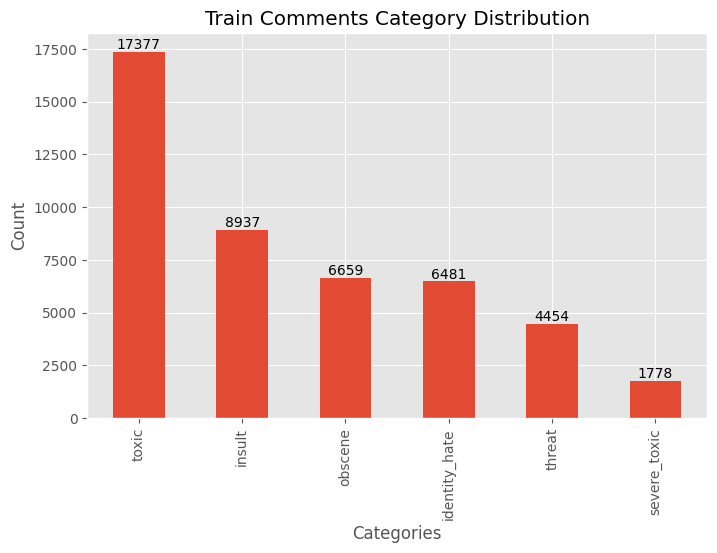

In [46]:
plot_category_distribution(train_df, toxicity_columns, title="Train Comments Category Distribution")

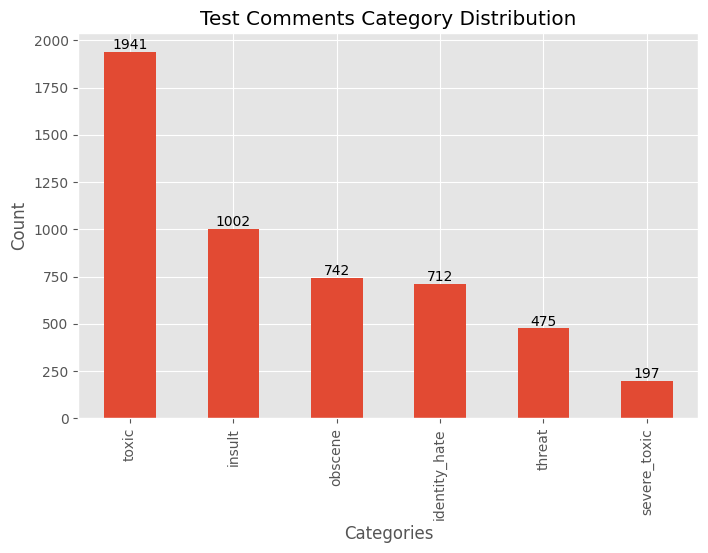

In [47]:
plot_category_distribution(test_df, toxicity_columns, title="Test Comments Category Distribution")

### 3.2 Data Export

In [48]:
train_df.to_csv(JIGSAW_INTERIM["train"], index=False)
test_df.to_csv(JIGSAW_INTERIM["test"], index=False)